# DeepSeek整体架构

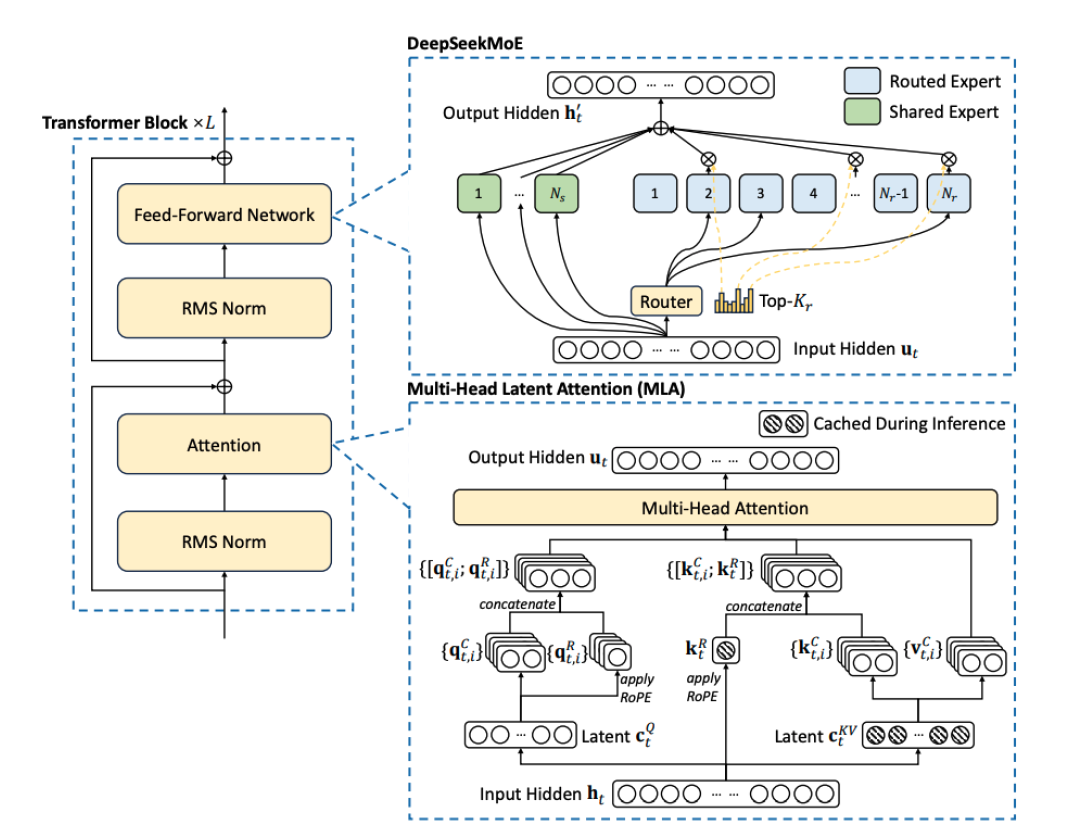

假设有个词表分类的任务

In [ ]:
class DeepSeek(nn.Module):
    """
    args 包含各种数据
        num_classes: 分类数量
        dim: 嵌入维度
        num_layers: 层数
    """
    def __init__(self):
        self.embeddings = nn.Embedding(args.num_classes, args.dim)  # 假设词汇表大小为100，嵌入维度为10
        self.layers = nn.ModuleList([DeepSeekLayer(layer_id, args) for layer_id in range(args.num_layers)])
        self.norm = RMSNorm(args.dim)
        self.head = ColumnParallelLinear(args.dim, args.num_classes)  # 分类头
    def forward(self, input_ids):
        input_embeds = self.embeddings(input_ids)  # 将输入ID转换为嵌入向量
        h = input_embeds
        for layer in self.layers:
            h = layer(h)
        h = self.norm(h)
        logits = self.head(h)  # 获取分类结果
        return logits

In [ ]:
class DeepSeekLayer(nn.Module):
    """
    这里参考上图的TransformerLayer
    """
    
    def __init__(self, layer_id, args):
        super().__init__()
        self.attn = MLA(args)
        self.ffn = MoE(args)
        self.attn_norm = RMSNorm(args.dim)
        self.ffn_norm = RMSNorm(args.dim)
    
    def forward(self, x):
        x = x + self.attn(self.attn_norm(x))
        x = x + self.ffn(self.ffn_norm(x))
        return x
    

# DeepSeekMoE



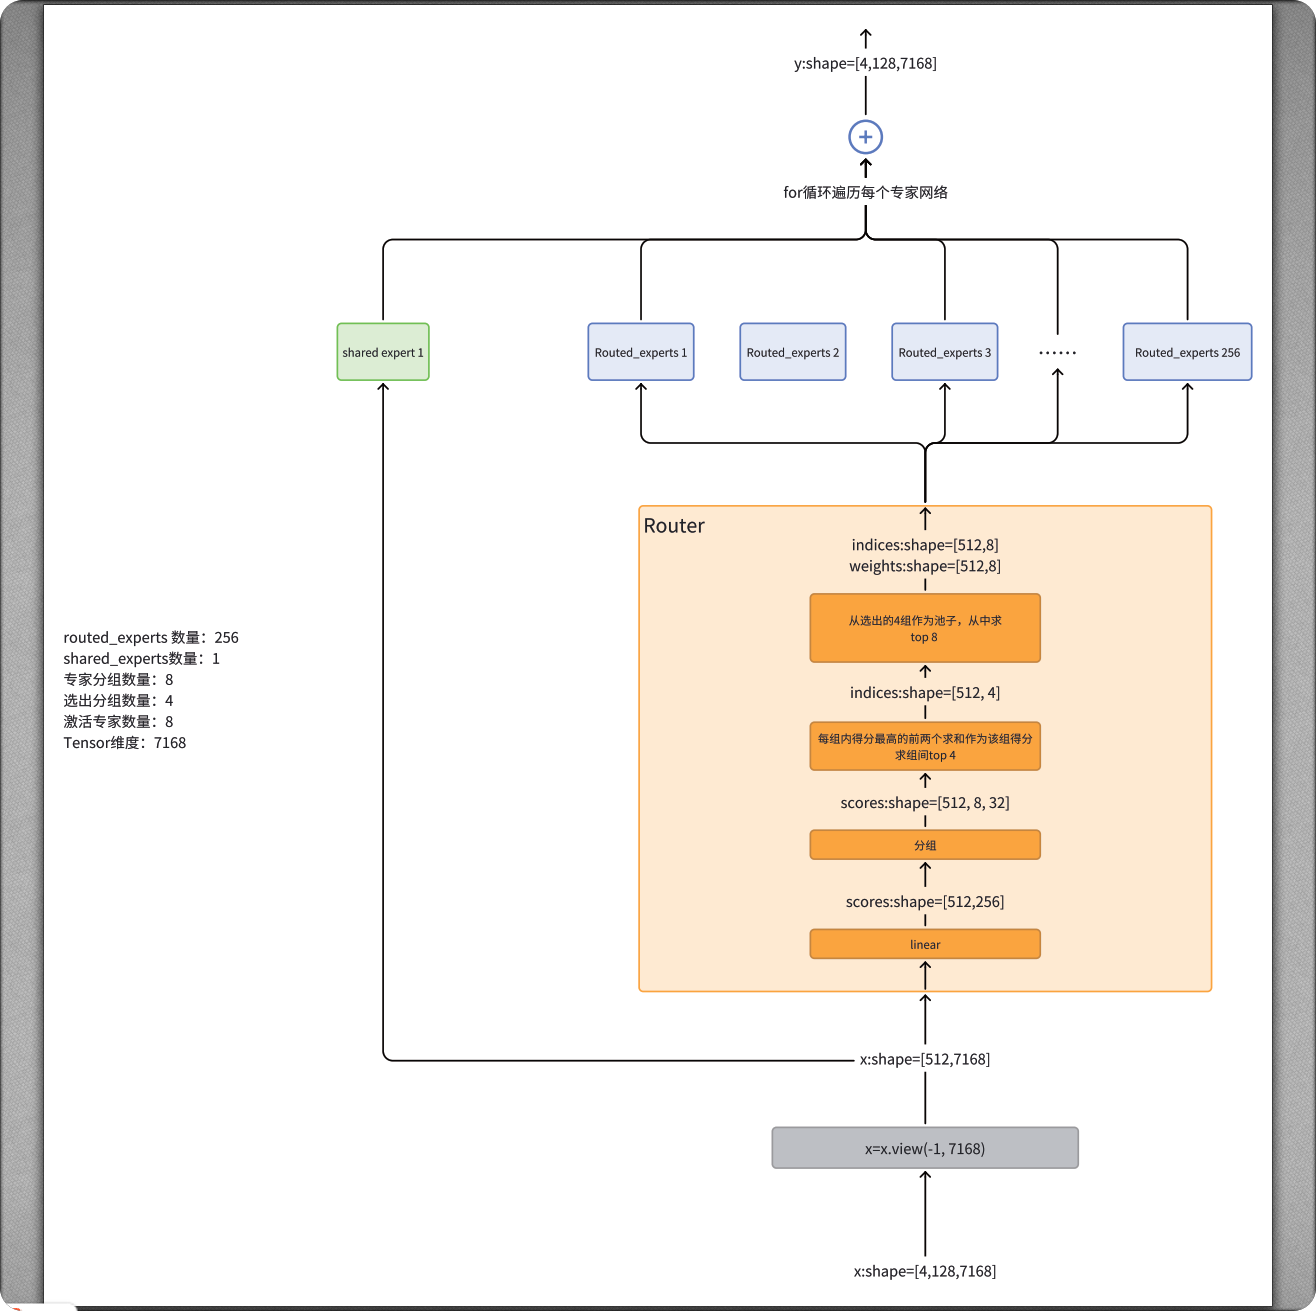

## 其中使用的基础函数

In [ ]:
import torch
# topk函数
# 在PyTorch中，torch.topk函数⽤于返回输⼊张量中指定维度上的前k个最⼤元素及其对应的索引。
x = torch.tensor([[3, 1, 4],
                [1, 5, 9],
                [2, 6, 5]])

values, indices = torch.topk(x, k=2, dim=1)

values, indices, x.size(), values.size(), indices.size()


(tensor([[4, 3],
         [9, 5],
         [6, 5]]),
 tensor([[2, 0],
         [2, 1],
         [1, 2]]),
 torch.Size([3, 3]),
 torch.Size([3, 2]),
 torch.Size([3, 2]))

In [11]:
# scatter_函数
# ⼀个原地操作函数，它的主要⽤途是依据给定的索引，把源张量中的元素位置的索引改为src

# torch.scatter_(dim, index, src)， 其中index必须和⽬标张量兼容

indices=torch.tensor([[0, 2],
                      [1, 2],
                      [1, 2]])
 
torch.zeros([3,3]).scatter_(1, indices, 100)


tensor([[100.,   0., 100.],
        [  0., 100., 100.],
        [  0., 100., 100.]])

In [13]:
# gather它可以根据给定的索引从输⼊张量中收集元素，从⽽构建⼀个新的张量。(与scatter互为反操作)

# torch.gather(input, dim, index)

input_tensor = torch.tensor([[10, 20, 30],
 [40, 50, 60],
 [70, 80, 90]])
 
index_tensor = torch.tensor([[2, 0],
 [1, 2],
 [0, 1]]) 
output = torch.gather(input_tensor, dim=1, index=index_tensor)
output

tensor([[30, 10],
        [50, 60],
        [70, 80]])

In [14]:
# bincount操作： 统计⾮负整数张量中每个值出现的次数

# 创建输⼊张量 
input_tensor = torch.tensor([1, 1, 2, 2, 10])

# 统计每个值出现的次数 
output = torch.bincount(input_tensor)
output # 位置1为2是因为1出现了两次，位置2为2是因为2出现了两次，位置10为1是因为10出现了一次，其他位置为0表示对应的值没有出现过。


tensor([0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 1])

In [ ]:
# where 可以根据给定的条件对张量元素进⾏选择性操作，类似于Python中的三元运算符。返回满⾜条件的元素的索引

# 创建⼀个张量 
input_tensor = torch.tensor([[1, 2], [3, 4]])

# 使⽤ torch.where 获取满⾜条件的元素的索引 
indices = torch.where(input_tensor == 2)
indices # 返回满足条件的元素的索引列表，(tensor([0]), tensor([1]))表示满足条件的元素位于第0行第1列。




(tensor([0]), tensor([1]))

## 路由专家Expert

其实就是之前的SwiGLU

In [ ]:

class Expert(nn.Module):
    def __init__(self, args):
        super().__init__()
        self.w1 = nn.Linear(args.dim, args.dim * 4)
        self.w2 = nn.Linear(args.dim * 4, args.dim)
        self.w3 = nn.Linear(args.dim, args.dim) # 充当门控制
        
    def forward(self, x):
        return self.w2(F.silu(self.w1(x))*self.w3(x))
    

## 共享专家MLP

暂时还没学这里的几个Linear的特殊之处， 样子就是SwiGLU

In [ ]:
# 多个共享专家都整合到了⼀个⽹络，是⼀个MLP⽹络，只是根据个数不同扩展了中间层维度 
 
 def MLP(nn.Module):
 def __init__(self):
 self.w1 = ColumnParallelLinear(dim, inter_dim)
 self.w2 = RowParallelLinear(inter_dim, dim)
 self.w3 = ColumnParallelLinear(dim, inter_dim) 
 def forward(self, x):
 return self.w2(F.silu(self.w1(x)) * self.w3(x))

## 路由函数Gate

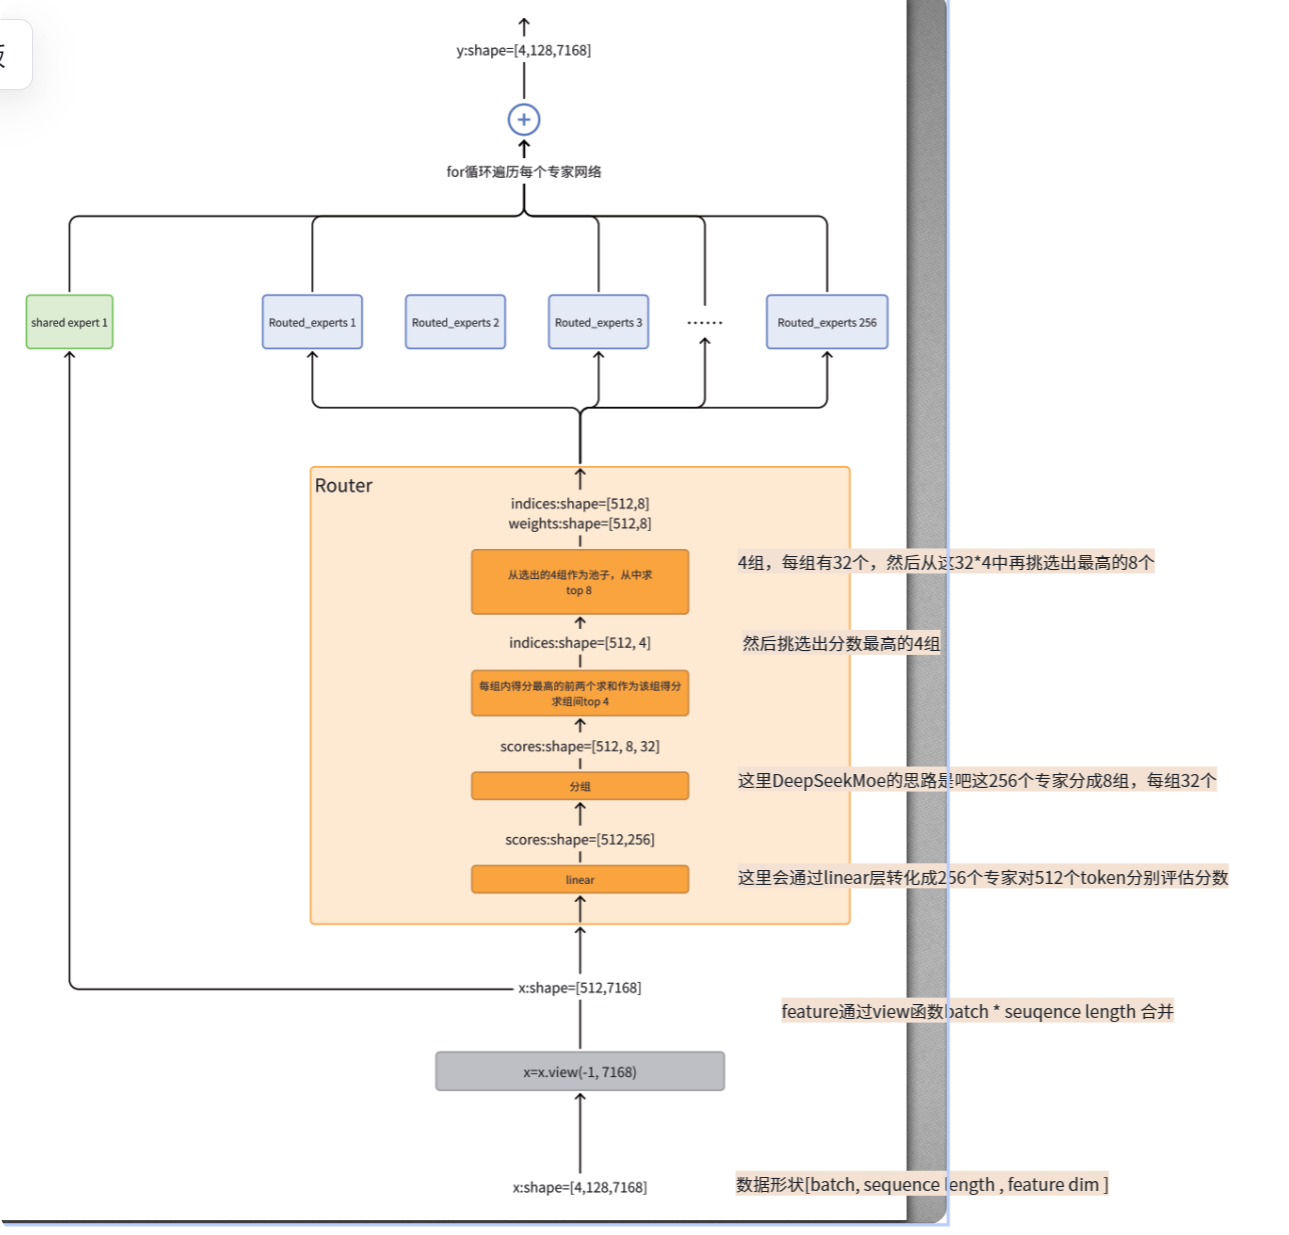

Gate函数当中会有个 weight 和 bias 这两个权重分别是用来：

self.bias 不参与运算主要是为了负载均衡，如果频繁出现选择固定第几个专家， bias的存在可以调整

self.weight 主要是相当于第i个专家的能力画像

In [ ]:
class Gate(nn.Module):
    """
    输入：
    x : (batch_size* seq_len, dim)的张量
    
    输出：
    weigts(batch_size* seq_len, topk : 每个专家输出的系数
    indices(batch_size* seq_len, topk) : 每个输入激活的专家索引
    """
    
    def __init__(self, args):
        self.topk = args.num_activated_experts # 每次激活多少专家
        self.n_groups = args.num_expert_groups # 专家分成多少组
        self.topk_groups = args.num_limited_groups # 只从多少组里面选专家， 上图中这个值就是4
        self.weight = nn.Parameter(torch.empty(args.num_routed_experts, args.dim)) # 初始化256个专家的参数
        self.bias = nn.Parameter(torch.empty(args.num_routed_experts)) # 初始化256个专家的偏置参数
        
    def forward(self, x):
        scores = linear(x, self.weight) # X*W^T  , 得到(batch_size* seq_len, num_routed_experts)
        scores = scores.sigmoid()
        scores = scores.view(x.size(0), self.n_groups, -1)# 将scores进行分组， (batch_size* seq_len, n_groups, num_routed_experts//n_groups)
        group_scores = scores.topk(2, dim=-1)[0].sum(dim=-1) # scores.topk(2, dim=-1)代表每组选取最大的两个，然后[0]代表把值取出来，sum(dim=-1)代表把每组的topk值相加，得到(batch_size* seq_len, n_groups)
        
        indices = group_scores.topk(self.topk_groups, dim=-1)[1] # 选择得分最⾼的4个组， 得到(batch_size* seq_len, topk_groups)
        mask = torch.zeros_like(scores[..., 0]).scatter_(1, indices, True) # 创建一个和 scores[..., 0]的(batch_size* seq_len, n_groups)形状的向量
        scores = (scores * mask.unsqueeze(-1)).flatten(1) # 将mask扩展到与scores相同的形状，并将不被选中的专家的分数置为0，然后将scores展平为(batch_size* seq_len, num_routed_experts)
        indices = torch.topk(scores, self.topk, dim=-1)[1] # 从剩余的专家中选择得分最高的topk个专家，得到(batch_size* seq_len, topk)
        weights = scores.gather(1, indices) # 根据选中的专家索引从scores中获取对应的权重，得到(batch_size* seq_len, topk)
        return weights, indices

## 正式开始手搓DeepseekMoe

In [ ]:
class MoE(nn.Module):
    def __init__(self, args):
        super().__init__()
        self.num_routed_experts = args.num_routed_experts # 路由专家的数量
        self.num_activated_experts = args.num_activated_experts # 每次激活的专家数量
        self.gate = Gate(args) # 这个是Router函数
        
       
        self.experts = nn.ModuleList([Expert(args) for _ in range(args.num_experts)])  # 路由专家网络
        self.shared_experts = MLP(args.dim, args.dim) # 共享专家网络
        
    def __forward__(self, x):
        """
        x  : [batch_size * seq_len, hidden_size]
        y : [batch_size * seq_len, hidden_size] 用来保存经过专家处理后的结果
        """
        
        weigts, indices = self.gate(x) # 这里每次Router会输出一个专家的权重 和 对应选择的专家的索引
        counts = torch.bincount(indices.flatten(), minlength=self.num_activated_experts).tolist() # 这里主要是统计 [batch_size * num_activated_experts] 这个索引中每个专家被选择的次数
        # 下面一部分对于每个专家来讲的， 先找到被激活的专家，然后再找这个专家需要处理的样本索引
        for i in range(self.num_activated_experts):
            if counts[i] > 0:
                continue
            
            expert = self.experts[i] # 对于被选择的i专家来说
            idx, top = torch.where(incides == i) # 找到i专家需要处理的几个样本索引
            y = expert(x[idx]) * weights[idx, top, None] # 用对应的专家进行处理并且乘以对应的权重
        
        z = self.shared_experts(x)
        return y + z
            
        